In [45]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia
from boulder_statistics.analysis.fit_params.weibull_fit_params import WeibullFitParams

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [46]:
power_law_db = pl.read_parquet(r"MLE_random_sample_fit_data\PowerLaw")
weibull_db = pl.read_parquet(r"MLE_random_sample_fit_data\Weibull").filter(pl.col("k_err").is_not_nan())
log_normal_db = pl.read_parquet(r"MLE_random_sample_fit_data\LogNormal").filter(pl.col("mu_err").is_not_nan())

In [47]:
power_law_db

seed,aic,bic,numb_alphas,s_max_fitting_alpha,s_min_fitting_alpha,q,g_mu,g_std,q_err,g_mu_err,g_std_err,LAD_min,J_min,min_alpha_to_consider
i32,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f64,i32
40723,5.1034e6,5.1035e6,412506,34166.764882,22.776133,0.862464,0.510082,0.094711,NaN,NaN,NaN,0,0.7,0
38182,5.1358e6,5.1358e6,409781,34166.764882,23.497827,0.781697,0.516619,0.098478,NaN,NaN,NaN,0,0.7,0
41008,5.1384e6,5.1384e6,412506,20845.303305,22.776133,0.809751,0.506503,0.098301,NaN,NaN,NaN,0,0.7,0
87813,5.0627e6,5.0628e6,409781,34166.764882,23.497827,0.945408,0.465644,0.091918,NaN,NaN,NaN,0,0.7,0
52941,5.1150e6,5.1151e6,409781,13621.267699,23.497827,0.959202,0.445171,0.093353,NaN,NaN,NaN,0,0.7,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
28994,5.0404e6,5.0405e6,406709,20845.303305,24.917094,0.946173,0.499573,0.082836,NaN,NaN,NaN,0,0.7,0
11740,5.0449e6,5.0450e6,406709,20845.303305,24.917094,0.920236,0.527698,0.084,NaN,NaN,NaN,0,0.7,0
30923,5.1231e6,5.1231e6,412506,20845.303305,22.776133,0.776555,0.560636,0.089385,NaN,NaN,NaN,0,0.7,0


In [48]:
weibull_db.group_by("numb_alphas").agg()

numb_alphas
i64
412506
406709
409781


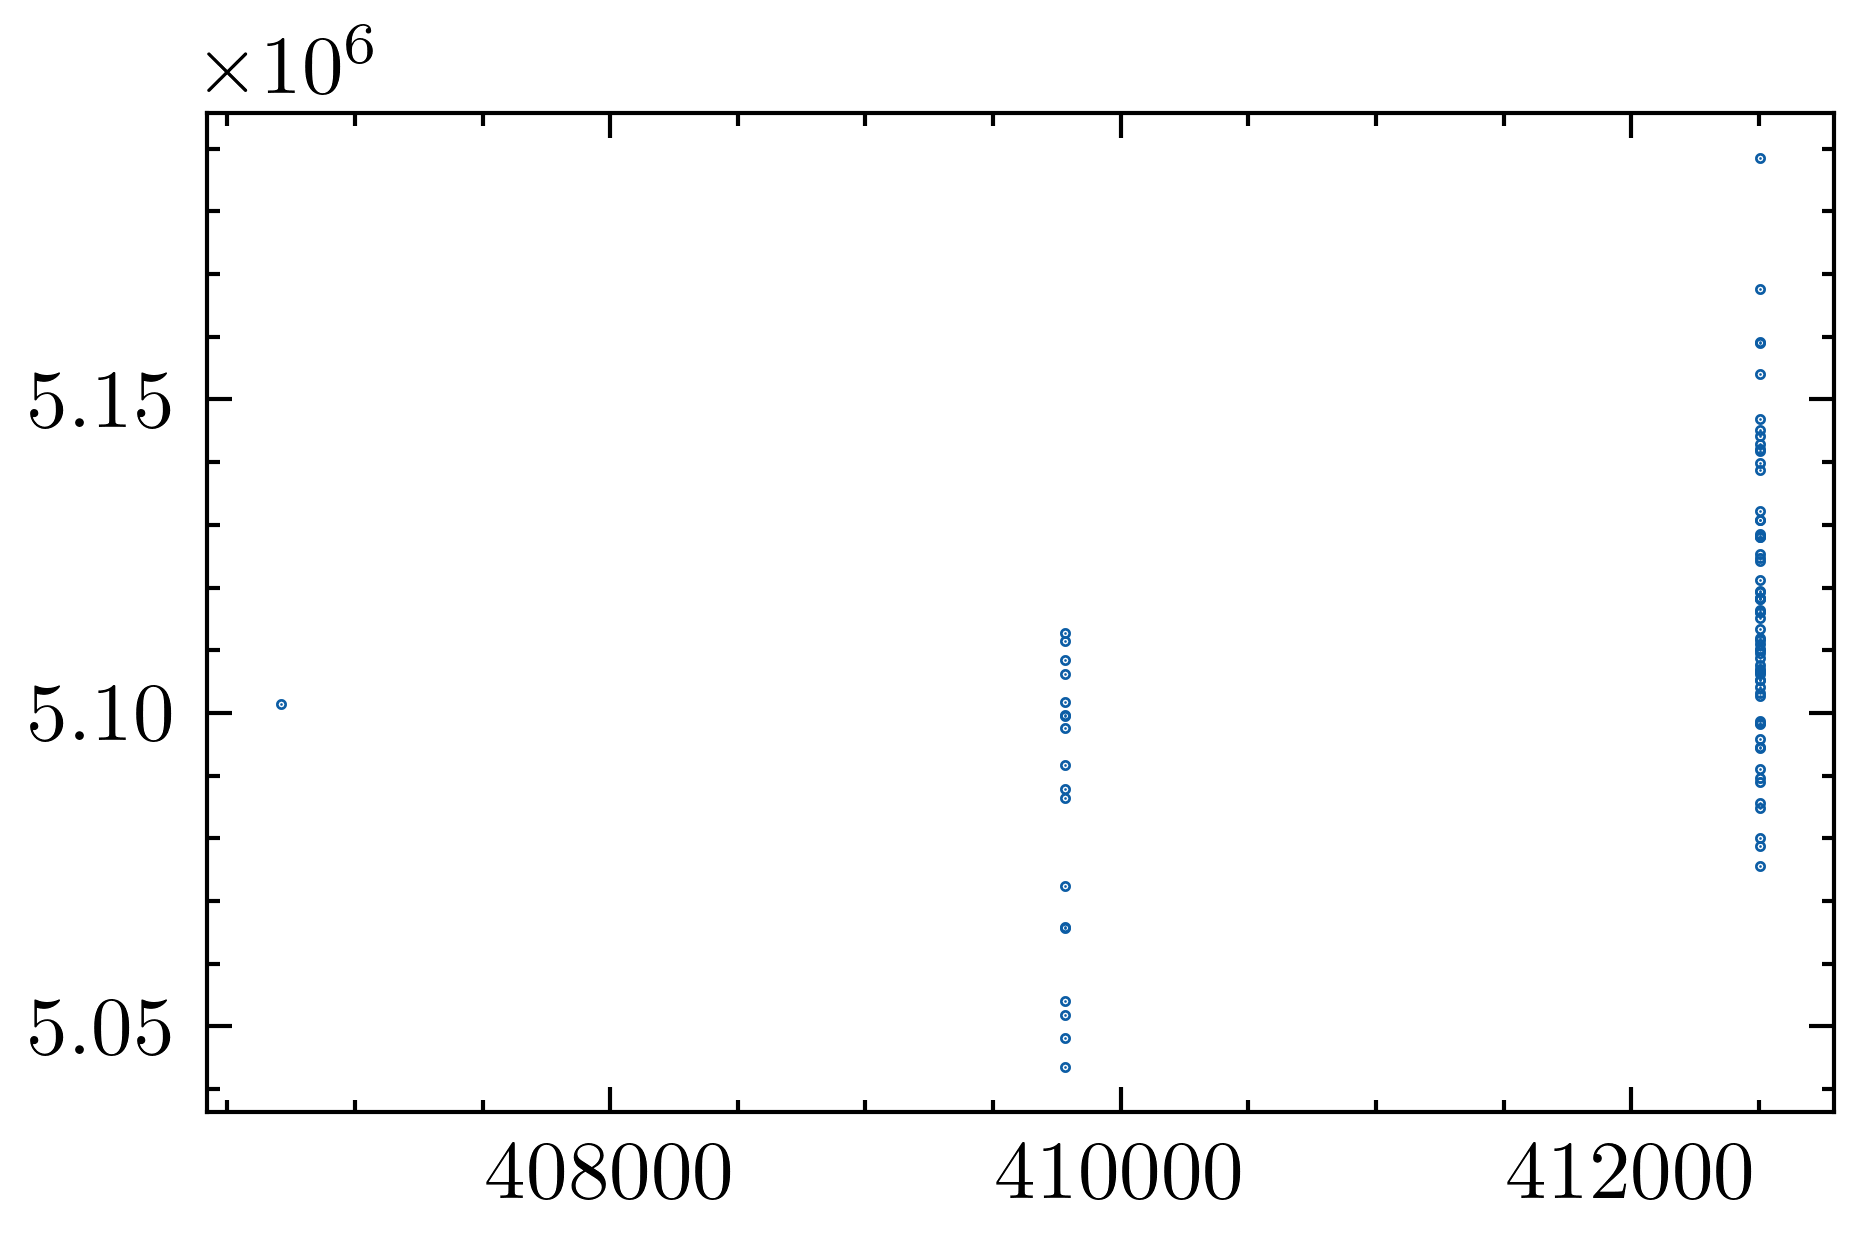

In [49]:
plt.scatter(weibull_db["numb_alphas"], weibull_db["aic"], s =0.1)

In [50]:
columns_to_select = ["aic", "numb_alphas"]

aic_db = pl.concat([
    power_law_db.select(columns_to_select).with_columns(pl.lit("PL").alias("fit_type")),
    weibull_db.select(columns_to_select).with_columns(pl.lit("W").alias("fit_type")),
    log_normal_db.select(columns_to_select).with_columns(pl.lit("LN").alias("fit_type"))
]) # .filter(pl.col("numb_alphas") == 412506)

aic_db

aic,numb_alphas,fit_type
f64,i64,str
5.1034e6,412506,"""PL"""
5.1358e6,409781,"""PL"""
5.1384e6,412506,"""PL"""
5.0627e6,409781,"""PL"""
5.1150e6,409781,"""PL"""
…,…,…
5.0952e6,412506,"""LN"""
5.0397e6,409781,"""LN"""
5.1394e6,412506,"""LN"""


In [51]:
aic_db = aic_db.join(
        aic_db.group_by("numb_alphas").agg(pl.col("aic").min().alias("min_aic_for_numb_alphas")),
        on = "numb_alphas",
    ).with_columns(
        (pl.col("aic") - pl.col("min_aic_for_numb_alphas")).alias("delta_aic")
    )

aic_db

aic,numb_alphas,fit_type,min_aic_for_numb_alphas,delta_aic
f64,i64,str,f64,f64
5.1034e6,412506,"""PL""",5.0647e6,38727.024052
5.1358e6,409781,"""PL""",5.0343e6,101484.079009
5.1384e6,412506,"""PL""",5.0647e6,73697.826288
5.0627e6,409781,"""PL""",5.0343e6,28476.655205
5.1150e6,409781,"""PL""",5.0343e6,80723.384978
…,…,…,…,…
5.0952e6,412506,"""LN""",5.0647e6,30553.243699
5.0397e6,409781,"""LN""",5.0343e6,5383.730256
5.1394e6,412506,"""LN""",5.0647e6,74758.824455


In [52]:
aic_db.group_by("fit_type").agg(
    pl.col("delta_aic").mean().alias("rel_mean_aic"),
    pl.col("delta_aic").std().alias("std_aic"),
    pl.col("delta_aic").min().alias("rel_min_aic"),
    pl.col("delta_aic").max().alias("rel_max_aic"),
    pl.len()
)

fit_type,rel_mean_aic,std_aic,rel_min_aic,rel_max_aic,len
str,f64,f64,f64,f64,u32
"""LN""",42049.144148,20183.499036,0.0,115878.878194,280
"""PL""",62151.812613,23138.142569,0.0,131931.607824,260
"""W""",52125.501156,22359.990764,9297.727848,123846.122283,85


In [53]:
import polars as pl

types = aic_db["fit_type"].unique().sort().to_list()

samples = {
    t: aic_db.filter(pl.col("fit_type") == t)["delta_aic"].to_numpy()
    for t in types
}

for t in types:
    others = [o for o in types if o != t]

    a = samples[t]
    b = samples[others[0]]
    c = samples[others[1]]

    p = (
        (a[:, None, None] < b[None, :, None]) &
        (a[:, None, None] < c[None, None, :])
    ).mean()

    print(f"P(AIC {t} < ({others[0]}, {others[1]})) = {100*p:.3f}%")

P(AIC LN < (PL, W)) = 53.807%
P(AIC PL < (LN, W)) = 16.158%
P(AIC W < (LN, PL)) = 30.031%
